In [1]:
import os
import glob
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
PR_REPO_ROOT = "/home/felix_jaspersen/Repositories/bo_pr"
BOUNCE_REPO_ROOT = "/home/felix_jaspersen/Repositories/bounce"

# The benchmark problems we want to plot
BENCHMARKS = [
    "ackley13", "ackley13_TR",
    "ackley53", "ackley53_TR",
    "svm", "svm_TR"
]

# Map each benchmark to its specific Bounce directory for q=1.
BOUNCE_PATHS = {
    "ackley13": "results/ackley13/q_1",
    "ackley13_TR": "results/ackley13_TR/q_1",
    "ackley53": "results/ackley53/q_1",
    "ackley53_TR": "results/4060176380/05-11-2026-13:01:39:429206",
    "svm": "results/svm/q_1",
    "svm_TR": "results/240410373/05-13-2026-11:36:50:736181",
}

In [3]:
# ==========================================
# 2. DATA EXTRACTION FUNCTIONS
# ==========================================
def aggregate_runs(run_arrays):
    """
    Takes a list of 1D numpy arrays (from different seeds) and returns the mean and std.
    It automatically pads shorter runs with their last observed value (standard BO practice).
    """
    if not run_arrays:
        return None, None
        
    max_len = max(len(arr) for arr in run_arrays)
    padded = []
    for arr in run_arrays:
        pad_width = max_len - len(arr)
        # Pad with the last value (edge) if the run crashed or stopped early
        padded.append(np.pad(arr, (0, pad_width), mode='edge'))
        
    padded = np.array(padded)
    return np.mean(padded, axis=0), np.std(padded, axis=0)

def get_pr_data(benchmark):
    """Loads PR's .pt files and flips them back to minimization."""
    pattern = os.path.join(PR_REPO_ROOT, "experiments", benchmark, "pr__ei", "*.pt")
    files = glob.glob(pattern)
    runs = []
    
    for f in files:
        data = torch.load(f, map_location="cpu")
        # PR maximizes the negated function. Multiply by -1 to get the true minimum.
        min_incumbent = -1 * data["best_objs"].numpy()
        runs.append(min_incumbent)
        
    return runs

def get_bounce_data(benchmark):
    """Loads Bounce's headerless .csv.xz files and tracks the minimum."""
    rel_path = BOUNCE_PATHS.get(benchmark, "")
    pattern = os.path.join(BOUNCE_REPO_ROOT, rel_path, "**", "results.csv.xz")
    files = glob.glob(pattern, recursive=True)
    runs = []
    
    for f in files:
        # Load the CSV explicitly stating there is no header row
        df = pd.read_csv(f, header=None)
        
        # The objective value is always the last column
        # y_vals = df.iloc[:, -1].values
        y_vals = df.iloc[:200, -1].values
        
        # Track the lowest value seen so far (Minimization)
        incumbent = np.minimum.accumulate(y_vals) 
        runs.append(incumbent)
            
    return runs

In [4]:
# ==========================================
# 3. PLOTTING FUNCTION
# ==========================================
def plot_benchmark(benchmark):
    """Fetches data for both methods and plots them side-by-side."""
    pr_runs = get_pr_data(benchmark)
    bounce_runs = get_bounce_data(benchmark)

    if not pr_runs and not bounce_runs:
        print(f"No data found for {benchmark}. Check your folder paths. Skipping.")
        return

    plt.figure(figsize=(9, 5))

    # Plot PR
    if pr_runs:
        pr_mean, pr_std = aggregate_runs(pr_runs)
        x_pr = np.arange(len(pr_mean))
        plt.plot(x_pr, pr_mean, label="Probabilistic Reparameterization (PR)", color="blue", linewidth=2.5)
        plt.fill_between(x_pr, pr_mean - pr_std, pr_mean + pr_std, color="blue", alpha=0.2)

    # Plot Bounce
    if bounce_runs:
        bounce_mean, bounce_std = aggregate_runs(bounce_runs)
        x_bounce = np.arange(len(bounce_mean))
        plt.plot(x_bounce, bounce_mean, label="Bounce (q=1)", color="red", linewidth=2.5)
        plt.fill_between(x_bounce, bounce_mean - bounce_std, bounce_mean + bounce_std, color="red", alpha=0.2)

    # Aesthetics
    plt.title(f"Optimization Performance: {benchmark}", fontsize=16, fontweight="bold")
    plt.xlabel("Number of Evaluations (Iterations)", fontsize=14)
    plt.ylabel("Best Objective Value Found (Minimizing)", fontsize=14)
    plt.legend(fontsize=12, loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

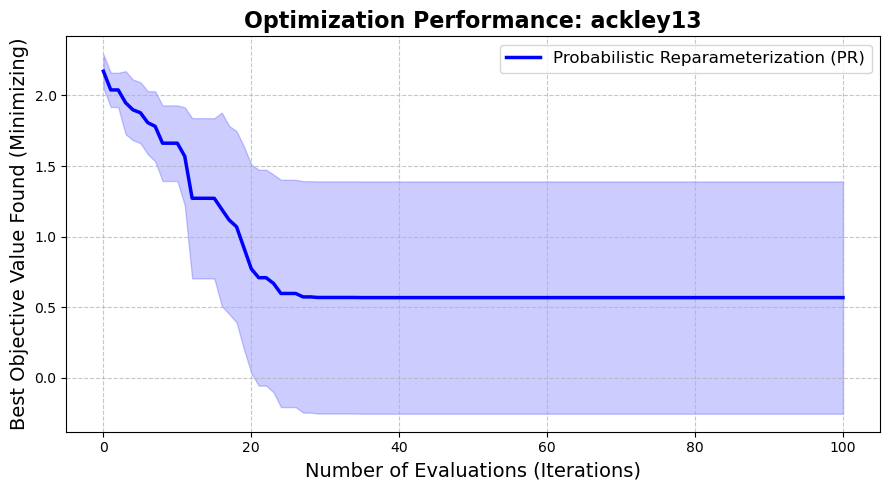

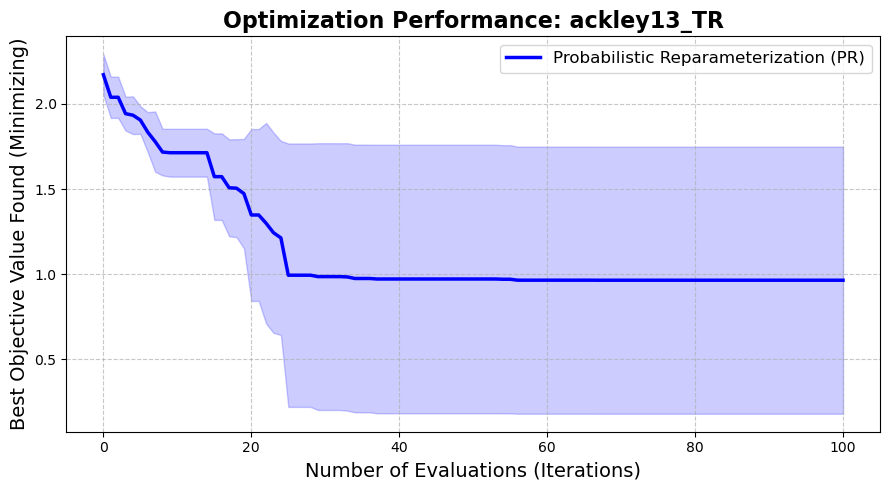

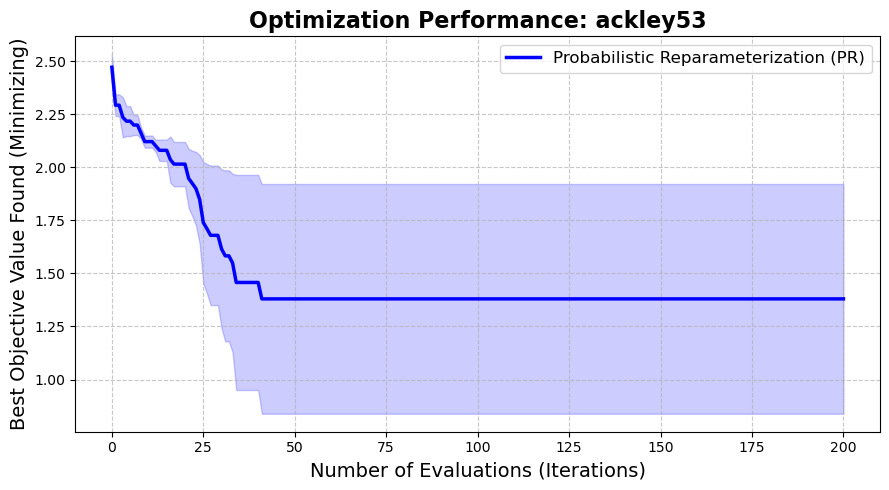

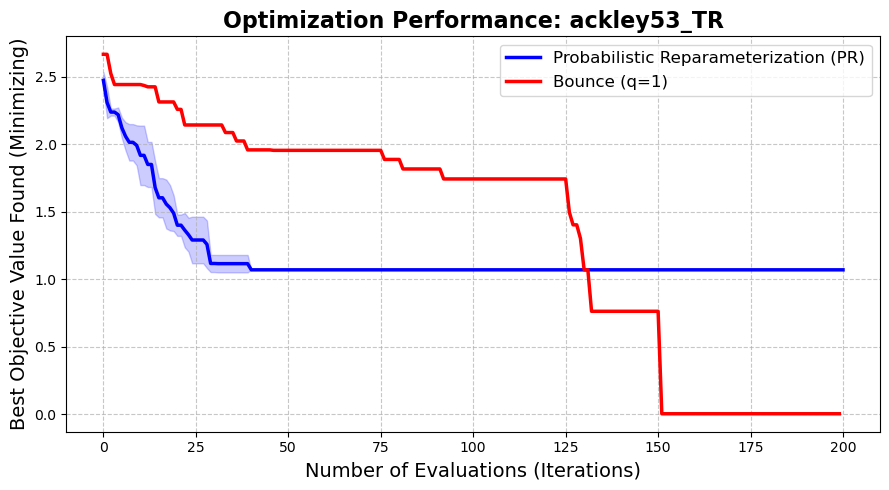

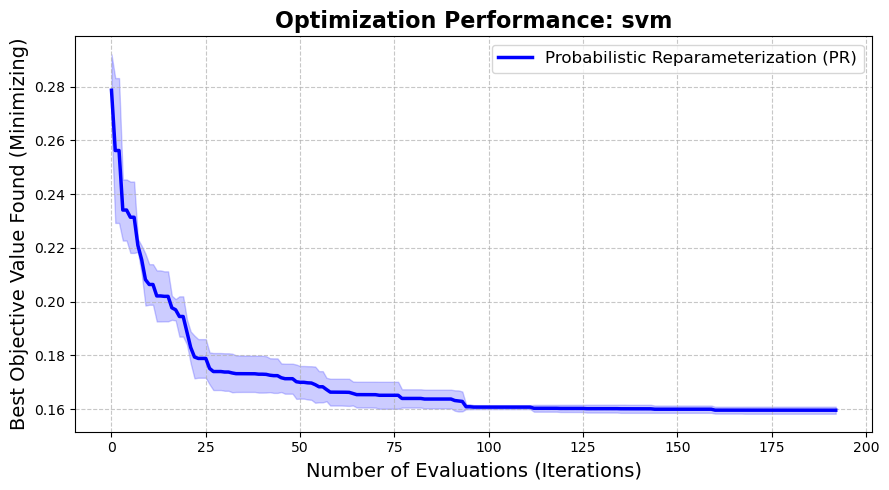

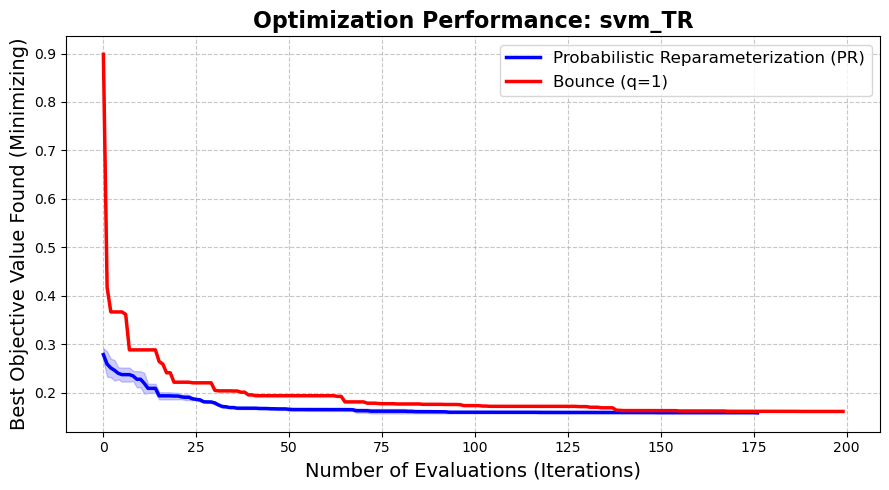

In [5]:
# ==========================================
# 4. EXECUTE
# ==========================================
for b in BENCHMARKS:
    plot_benchmark(b)

# Comments

## Ackley13

- As expected, trust regions do not seems to help on this low D case.
- Need to run Bounce on this

## Ackley53

- Need to up iterations to 200 for PR

## svm_TR

- PR performs better than Bounce here. Gives me the impression that mixedness is the larger challenge than HD in this example.
- PR: One run finished 197 iterations, where two others failed early. Why? On SVM you also see that all three runs stopped at 157 iterations due to time limit of 10 hours.
